In [1]:
#maybe dont run this on your system...
!mamba install fastcore=1.5.29 

warning  libmamba 'repo.anaconda.com', a commercial channel hosted by Anaconda.com, is used.
    
warning  libmamba Please make sure you understand Anaconda Terms of Services.
    
warning  libmamba See: https://legal.anaconda.com/policies/en/
[+] 0.0s

Pinned packages:

  - python=3.10


Transaction

  Prefix: /Users/zoe/.local/share/mamba/envs/tapas-upgrade

  All requested packages already installed


Transaction starting
[+] 0.0s

Transaction finished



In [2]:
%load_ext autoreload
%autoreload 2

import os
os.environ["SYNTHCITY_DEVICE"] = "cpu"

import tapas
from tapas.attacks.set_classifiers import RandomTargetedQueryFeature
from tapas.generators.generator import Raw
from utils.my_attack import MyAttack
from utils.benchmark_pipeline import BenchmarkPipeline
from tools.tapas.tapas_data_processors import AdultDataProcessor
import random




from tapas.generators.generator import ReprosynGenerator, Raw
from reprosyn.methods import DS_PRIVBAYES
from reprosyn.methods import DS_BAYNET
from tools.tapas.generators import BenchmarkGenerator, SynthcityGenerator

/Users/zoe/.local/share/mamba/envs/tapas-upgrade/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.


In [3]:
# !pip install tf_keras

In [4]:
data = tapas.datasets.TabularDataset.read("data/adult")
data = AdultDataProcessor.process_tapas_tabulardataset(data)
data = data.sample(frac = 0.05)  #downsample the data 
print(len(data.data))
ind = [int(random.random() * len(data.data))]

2261


In [5]:
my_dataset = data

In [6]:
benchmark_gen = BenchmarkGenerator(ReprosynGenerator, method_kwargs = {
    'reprosyn_class': DS_PRIVBAYES},
    param_kwargs = {'epsilon': 1.0
})

benchmark_gen.fit(my_dataset)
synthetic_data = benchmark_gen.generate(1000)
print(benchmark_gen.parameters)

{'epsilon': 1.0}


In [7]:
benchmark_gen.label

'DS_PRIVBAYES'

In [8]:
benchmark_gen.get_filename_label()

'DS_PRIVBAYES_epsilon=1.0'

In [6]:
benchmark_gen2 = BenchmarkGenerator(SynthcityGenerator, {'plugin_name': "ddpm"} , {})


benchmark_gen.fit(my_dataset)
synthetic_data = benchmark_gen.generate(1000)


[2025-05-07T14:08:52.119224+0100][43564][CRITICAL] module disabled: /Users/zoe/.local/share/mamba/envs/tapas-upgrade/lib/python3.10/site-packages/synthcity/plugins/generic/plugin_goggle.py
Epoch: 100%|█████████████████████| 1000/1000 [02:18<00:00,  7.22it/s, loss=1.39]


In [7]:
benchmark_gen2.get_filename_label()

'ddpm'

In [9]:
benchmark_gen3 = BenchmarkGenerator(Raw, {}, {})

In [10]:
benchmark_gen3.get_filename_label()

'Raw'

2261
estimating categorical probs
estimating approx kdes(histogram)
Attacking : <tools.tapas.generators.BenchmarkGenerator object at 0x1086038b0>
Generate datasets
COMPLEXITY:  2
COMPLEXITY:  10


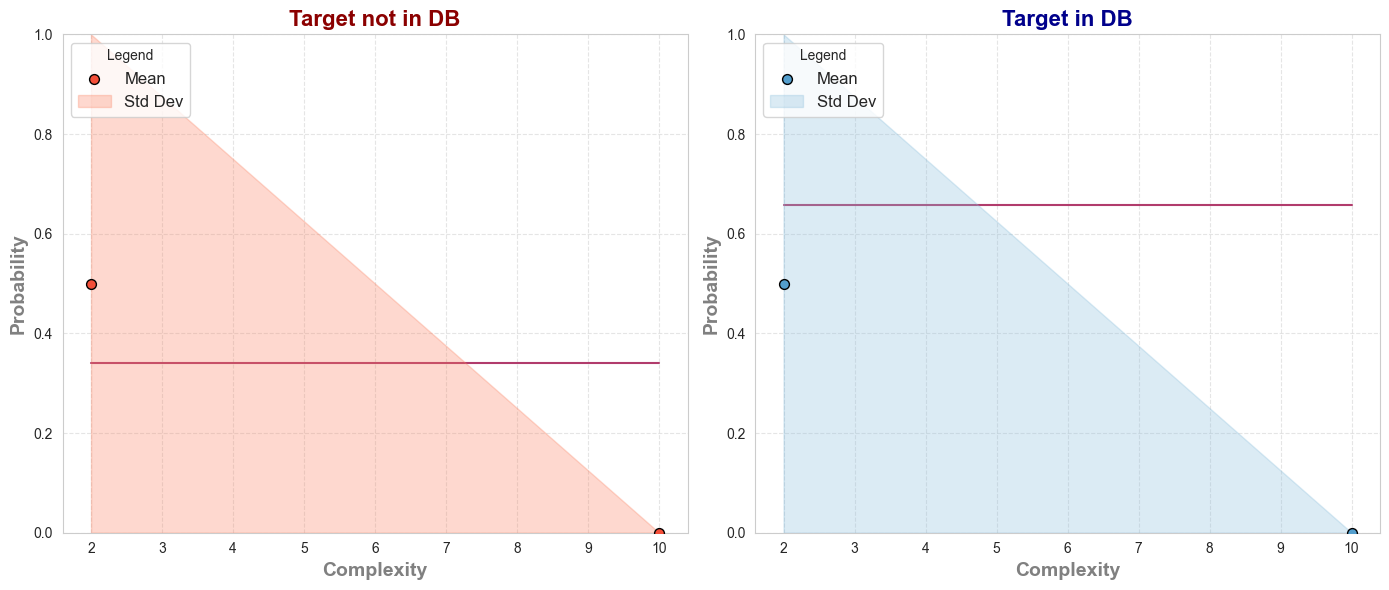

In [13]:
#TEST PIPELINE
data = tapas.datasets.TabularDataset.read("data/adult")
data = AdultDataProcessor.process_tapas_tabulardataset(data)
data = data.sample(frac = 0.05)  #downsample the data 
print(len(data.data))
ind = [int(random.random() * len(data.data))]

target_record = data.get_records(ind)
data.drop_records(ind, in_place=True)

attack = MyAttack(100, features=RandomTargetedQueryFeature(target_record,4,2000))

pipeline = BenchmarkPipeline(data, attack, [benchmark_gen], target_record=target_record)
pipeline.run([2,10], 10, 2)